Shape: (1875, 13)
Date Range: 2022-01-01 to 2023-12-30

Column Names:
['Date', 'Month', 'Year', 'Quarter', 'Day_of_Week', 'Product', 'Units_Produced', 'Units_Sold', 'Wastage_Units', 'Raw_Material_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_Pct']
=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   1875 non-null   datetime64[ns]
 1   Month                  1875 non-null   object        
 2   Year                   1875 non-null   int64         
 3   Quarter                1875 non-null   object        
 4   Day_of_Week            1875 non-null   object        
 5   Product                1875 non-null   object        
 6   Units_Produced         1875 non-null   int64         
 7   Units_Sold             1875 non-null   int64         
 8   Wastage_Units       

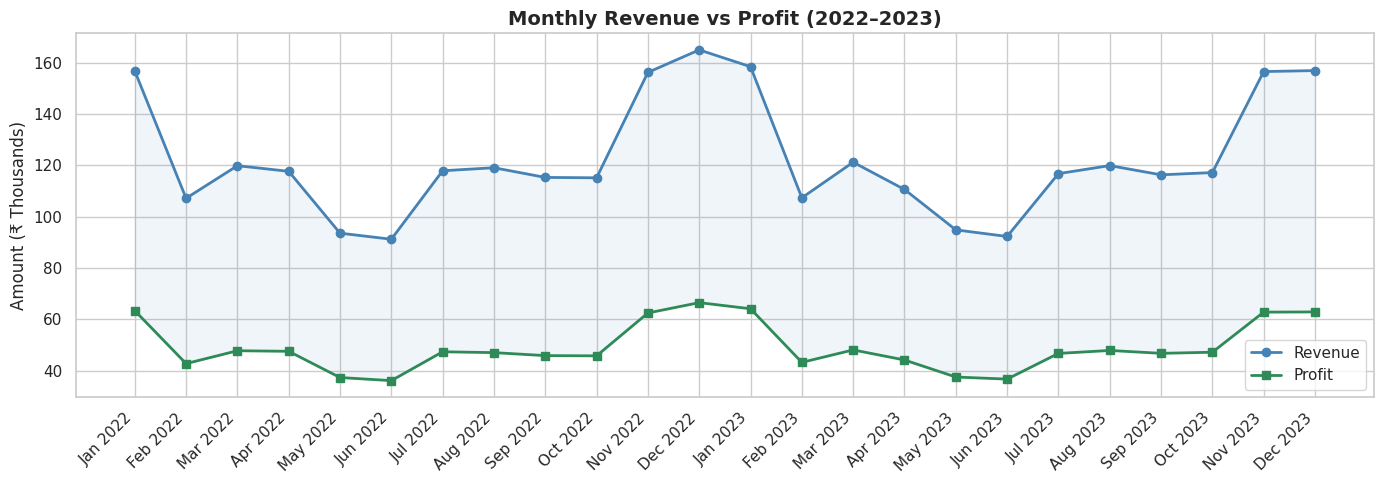


Chart saved as monthly_revenue_trend.png
=== PRODUCT PERFORMANCE ===
Product  Total_Revenue  Total_Profit  Avg_Margin  Total_Units_Sold  Total_Wastage
  Bread        1083126     410751.18       37.74             49233           5268
Cookies        1121145     447805.54       39.84             74743           8019
   Rusk         739920     320272.90       43.15             61660           6648


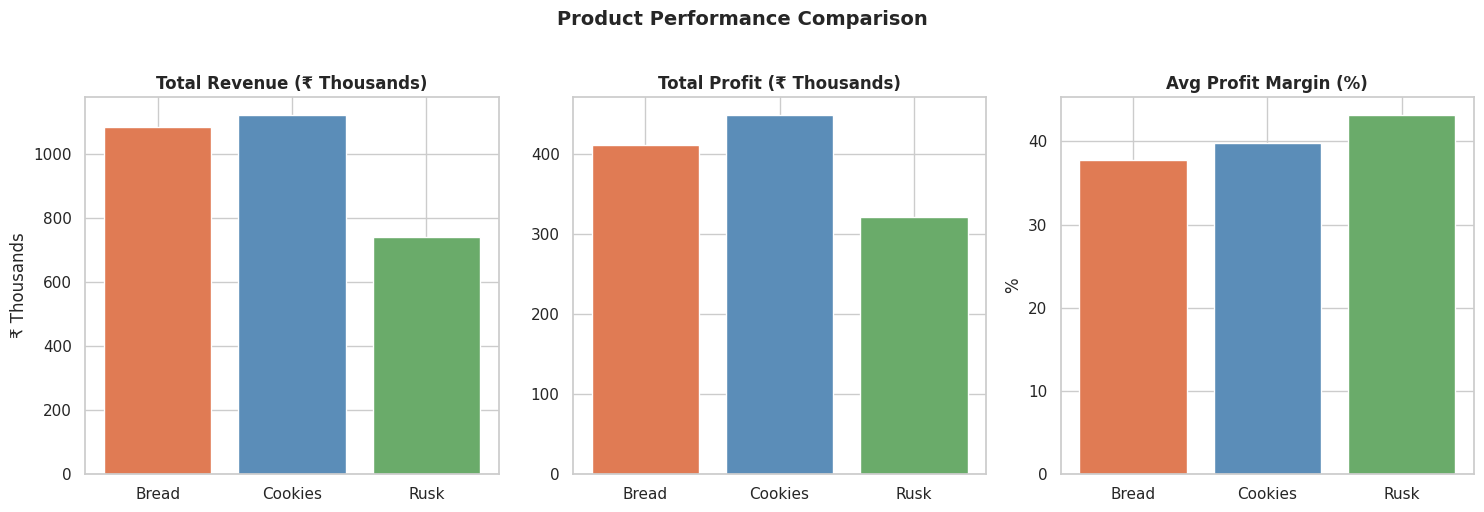


Chart saved as product_performance.png


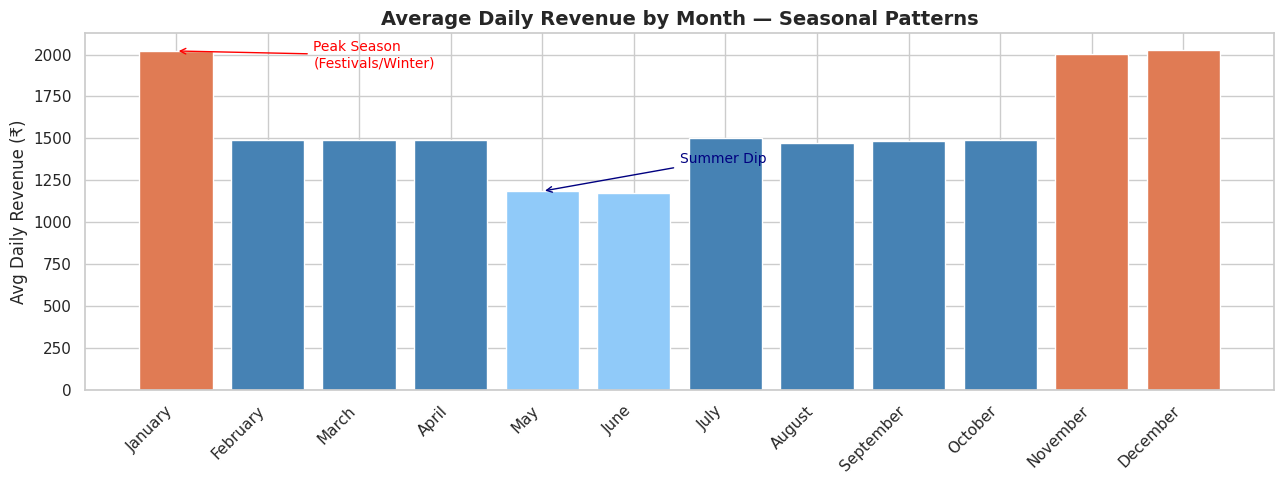


Chart saved as seasonal_demand.png


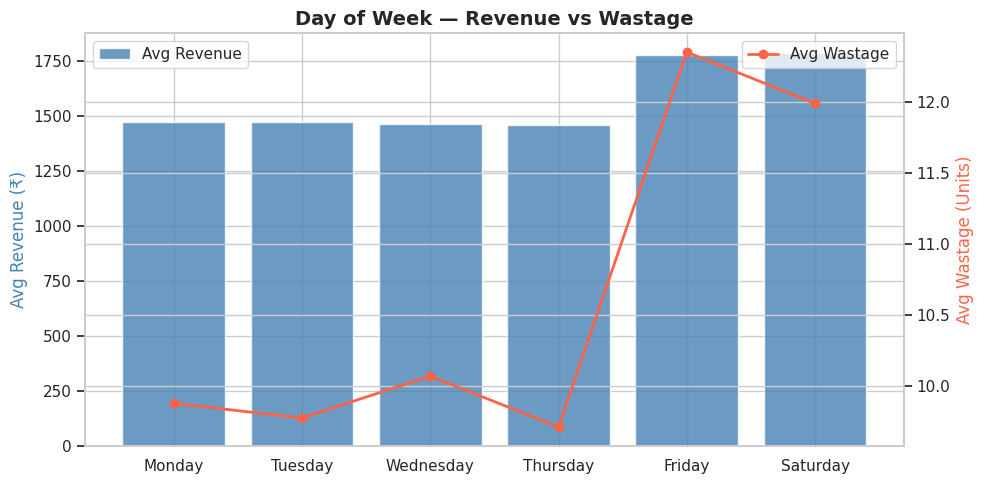


Chart saved as dow_performance.png
=== WASTAGE ANALYSIS ===
Product  Total_Produced  Total_Wastage  Wastage_Rate_Pct
  Bread           56083           5268              9.39
Cookies           84317           8019              9.51
   Rusk           69917           6648              9.51


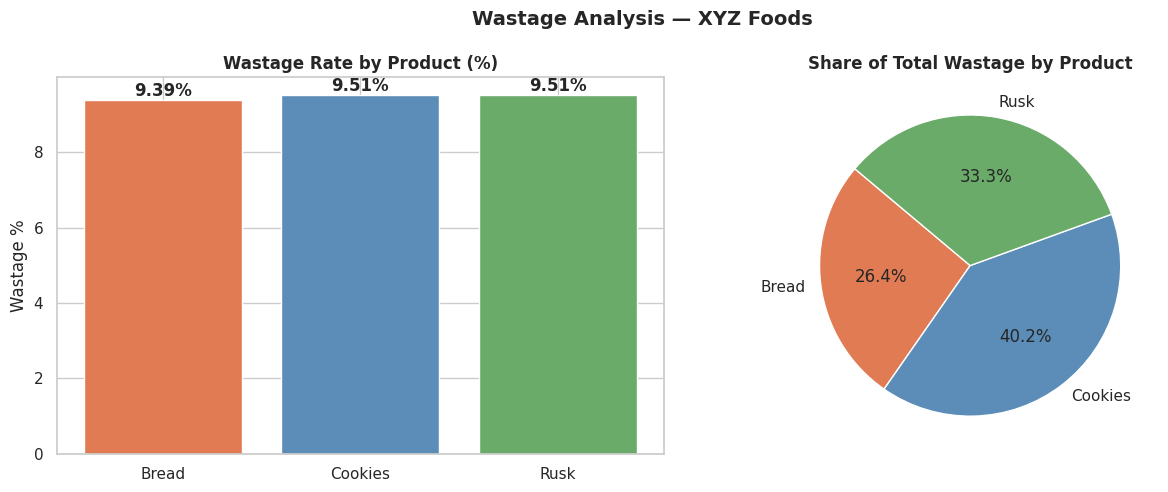


Chart saved as wastage_analysis.png
=== YEAR ON YEAR COMPARISON ===
 Year  Revenue    Profit      Cost  Units_Sold  Wastage  Avg_Margin
 2022  1475340 590331.33 885008.67       93012    10055       40.23
 2023  1468851 588498.29 880352.71       92624     9880       40.26

Revenue Growth  2022→2023 : -0.4%
Profit Growth   2022→2023 : -0.3%


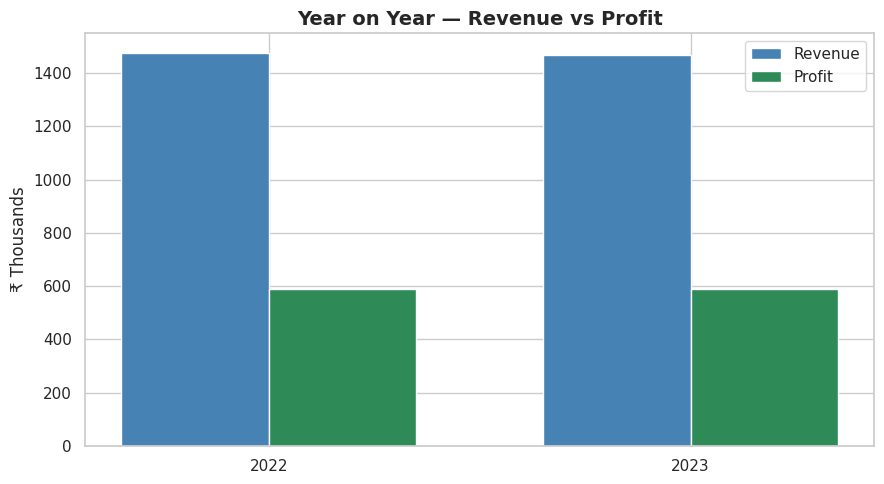


Chart saved as yoy_comparison.png
        KEY BUSINESS INSIGHTS
Best Revenue Month    : December
Lowest Revenue Month  : June
Highest Revenue Product: Cookies
Best Margin Product   : Rusk
Highest Wastage Product: Cookies
Best Sales Day        : Saturday
Overall Profit Margin : 40.2%


In [2]:
'''
#XYZ Foods — Sales & Operations Analysis
#Tools: Python • Pandas • Matplotlib • Seaborn
#Dataset: 2 Years of Daily Sales Data (Jan 2022 – Dec 2023)
#Author: Satjot Singh Bhatia

Objective
Analyse 2 years of bakery sales data to uncover:
- Revenue and profit trends over time
- Best and worst performing products
- Seasonal demand patterns
- Wastage and operational efficiency
- Day-of-week performance patterns
'''
## Step 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Chart styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## Step 2 — Load Dataset

# Upload XYZ_Foods_sales_data.csv
# Then run this cell

df = pd.read_csv('XYZ_Foods_sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Shape: {df.shape}')
print(f'Date Range: {df.Date.min().date()} to {df.Date.max().date()}')
print(f'\nColumn Names:\n{list(df.columns)}')
df.head()

## Step 3 — Data Overview & Quality Check

print('=== DATASET INFO ===')
print(df.info())
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== BASIC STATISTICS ===')
df.describe().round(2)

## Step 4 — Business KPIs Summary

total_revenue   = df['Revenue_INR'].sum()
total_profit    = df['Profit_INR'].sum()
total_cost      = df['Raw_Material_Cost_INR'].sum()
total_produced  = df['Units_Produced'].sum()
total_sold      = df['Units_Sold'].sum()
total_wastage   = df['Wastage_Units'].sum()
avg_margin      = df['Profit_Margin_Pct'].mean()
wastage_rate    = (total_wastage / total_produced) * 100

print('=' * 45)
print('       XYZ Foods — 2 YEAR KPI SUMMARY')
print('=' * 45)
print(f'  Total Revenue       : ₹{total_revenue:>12,.0f}')
print(f'  Total Profit        : ₹{total_profit:>12,.0f}')
print(f'  Total Cost          : ₹{total_cost:>12,.0f}')
print(f'  Avg Profit Margin   :  {avg_margin:>11.1f}%')
print(f'  Units Produced      :  {total_produced:>12,}')
print(f'  Units Sold          :  {total_sold:>12,}')
print(f'  Total Wastage Units :  {total_wastage:>12,}')
print(f'  Wastage Rate        :  {wastage_rate:>11.1f}%')
print('=' * 45)

## Step 5 — Monthly Revenue Trend

monthly = df.groupby(['Year', 'Month', df['Date'].dt.month.rename('MonthNum')])\
        .agg(Revenue=('Revenue_INR','sum'), Profit=('Profit_INR','sum')).reset_index()
monthly = monthly.sort_values(['Year','MonthNum'])
monthly['Period'] = monthly['Month'].str[:3] + ' ' + monthly['Year'].astype(str)


fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Revenue']/1000, marker='o', color='steelblue', linewidth=2, label='Revenue')
ax.plot(monthly['Period'], monthly['Profit']/1000,  marker='s', color='seagreen', linewidth=2, label='Profit')
ax.fill_between(range(len(monthly)), monthly['Revenue']/1000, monthly['Profit']/1000, alpha=0.08, color='steelblue')
ax.set_title('Monthly Revenue vs Profit (2022–2023)', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount (₹ Thousands)')
ax.set_xlabel('')
plt.xticks(range(len(monthly)), monthly['Period'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('monthly_revenue_trend.png', dpi=150)
plt.show()
print('\nChart saved as monthly_revenue_trend.png')

## Step 6 — Product Performance Comparison

product = df.groupby('Product').agg(
    Total_Revenue=('Revenue_INR','sum'),
    Total_Profit=('Profit_INR','sum'),
    Avg_Margin=('Profit_Margin_Pct','mean'),
    Total_Units_Sold=('Units_Sold','sum'),
    Total_Wastage=('Wastage_Units','sum')
).round(2).reset_index()

print('=== PRODUCT PERFORMANCE ===')
print(product.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#E07B54', '#5B8DB8', '#6AAB6A']

axes[0].bar(product['Product'], product['Total_Revenue']/1000, color=colors)
axes[0].set_title('Total Revenue (₹ Thousands)', fontweight='bold')
axes[0].set_ylabel('₹ Thousands')

axes[1].bar(product['Product'], product['Total_Profit']/1000, color=colors)
axes[1].set_title('Total Profit (₹ Thousands)', fontweight='bold')

axes[2].bar(product['Product'], product['Avg_Margin'], color=colors)
axes[2].set_title('Avg Profit Margin (%)', fontweight='bold')
axes[2].set_ylabel('%')

plt.suptitle('Product Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('product_performance.png', dpi=150)
plt.show()
print('\nChart saved as product_performance.png')

## Step 7 — Seasonal Demand Analysis

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

seasonal = df.groupby('Month').agg(
    Avg_Revenue=('Revenue_INR','mean'),
    Avg_Units_Sold=('Units_Sold','mean')
).reindex(month_order).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(seasonal['Month'], seasonal['Avg_Revenue'],
              color=['#E07B54' if m in ['November','December','January']
                     else '#90CAF9' if m in ['May','June']
                     else 'steelblue' for m in seasonal['Month']])
ax.set_title('Average Daily Revenue by Month — Seasonal Patterns', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Daily Revenue (₹)')
plt.xticks(rotation=45, ha='right')

# Annotations
ax.annotate('Peak Season\n(Festivals/Winter)', xy=(0, seasonal.loc[0,'Avg_Revenue']),
            xytext=(1.5, seasonal['Avg_Revenue'].max()*0.95),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)
ax.annotate('Summer Dip', xy=(4, seasonal.loc[4,'Avg_Revenue']),
            xytext=(5.5, seasonal['Avg_Revenue'].min()*1.15),
            arrowprops=dict(arrowstyle='->', color='navy'), color='navy', fontsize=10)
plt.tight_layout()
plt.savefig('seasonal_demand.png', dpi=150)
plt.show()
print('\nChart saved as seasonal_demand.png')

## Step 8 — Day of Week Performance

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
dow = df.groupby('Day_of_Week').agg(
    Avg_Revenue=('Revenue_INR','mean'),
    Avg_Wastage=('Wastage_Units','mean')
).reindex(day_order).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(dow['Day_of_Week'], dow['Avg_Revenue'], color='steelblue', alpha=0.8, label='Avg Revenue')
ax2.plot(dow['Day_of_Week'], dow['Avg_Wastage'], color='tomato', marker='o', linewidth=2, label='Avg Wastage')

ax1.set_title('Day of Week — Revenue vs Wastage', fontsize=14, fontweight='bold')
ax1.set_ylabel('Avg Revenue (₹)', color='steelblue')
ax2.set_ylabel('Avg Wastage (Units)', color='tomato')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('dow_performance.png', dpi=150)
plt.show()
print('\nChart saved as dow_performance.png')

## Step 9 — Wastage Analysis by Product

wastage = df.groupby('Product').agg(
    Total_Produced=('Units_Produced','sum'),
    Total_Wastage=('Wastage_Units','sum')
).reset_index()
wastage['Wastage_Rate_Pct'] = (wastage['Total_Wastage'] / wastage['Total_Produced'] * 100).round(2)

print('=== WASTAGE ANALYSIS ===')
print(wastage.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#E07B54','#5B8DB8','#6AAB6A']

axes[0].bar(wastage['Product'], wastage['Wastage_Rate_Pct'], color=colors)
axes[0].set_title('Wastage Rate by Product (%)', fontweight='bold')
axes[0].set_ylabel('Wastage %')
for i, v in enumerate(wastage['Wastage_Rate_Pct']):
    axes[0].text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

axes[1].pie(wastage['Total_Wastage'], labels=wastage['Product'], colors=colors,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Share of Total Wastage by Product', fontweight='bold')

plt.suptitle('Wastage Analysis — XYZ Foods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wastage_analysis.png', dpi=150)
plt.show()
print('\nChart saved as wastage_analysis.png')


## Step 10 — Year on Year Comparison

yoy = df.groupby('Year').agg(
    Revenue=('Revenue_INR','sum'),
    Profit=('Profit_INR','sum'),
    Cost=('Raw_Material_Cost_INR','sum'),
    Units_Sold=('Units_Sold','sum'),
    Wastage=('Wastage_Units','sum'),
    Avg_Margin=('Profit_Margin_Pct','mean')
).round(2).reset_index()

rev_growth = ((yoy.loc[1,'Revenue'] - yoy.loc[0,'Revenue']) / yoy.loc[0,'Revenue'] * 100)
profit_growth = ((yoy.loc[1,'Profit'] - yoy.loc[0,'Profit']) / yoy.loc[0,'Profit'] * 100)

print('=== YEAR ON YEAR COMPARISON ===')
print(yoy.to_string(index=False))
print(f'\nRevenue Growth  2022→2023 : {rev_growth:+.1f}%')
print(f'Profit Growth   2022→2023 : {profit_growth:+.1f}%')

x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, yoy['Revenue']/1000, width, label='Revenue', color='steelblue')
ax.bar(x + width/2, yoy['Profit']/1000,  width, label='Profit',  color='seagreen')
ax.set_title('Year on Year — Revenue vs Profit', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['2022', '2023'])
ax.set_ylabel('₹ Thousands')
ax.legend()
plt.tight_layout()
plt.savefig('yoy_comparison.png', dpi=150)
plt.show()
print('\nChart saved as yoy_comparison.png')

## Step 11 — Key Insights Summary

best_month = df.groupby('Month')['Revenue_INR'].sum().idxmax()
worst_month = df.groupby('Month')['Revenue_INR'].sum().idxmin()
best_product_rev = df.groupby('Product')['Revenue_INR'].sum().idxmax()
best_product_margin = df.groupby('Product')['Profit_Margin_Pct'].mean().idxmax()
highest_wastage_product = df.groupby('Product')['Wastage_Units'].sum().idxmax()
best_day = df.groupby('Day_of_Week')['Revenue_INR'].mean().idxmax()

print('=' * 50)
print('        KEY BUSINESS INSIGHTS')
print('=' * 50)
print(f'Best Revenue Month    : {best_month}')
print(f'Lowest Revenue Month  : {worst_month}')
print(f'Highest Revenue Product: {best_product_rev}')
print(f'Best Margin Product   : {best_product_margin}')
print(f'Highest Wastage Product: {highest_wastage_product}')
print(f'Best Sales Day        : {best_day}')
print(f'Overall Profit Margin : {df["Profit_Margin_Pct"].mean():.1f}%')
print('=' * 50)